### Assigment 13

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [2]:
# CSV file ko read kar ke DataFrame (df) mein store kar rahay hain
df = pd.read_csv("ecommerce_dataset.csv")

# Data ka shuruati roop (pehli 5 rows) dekhnay ke liye
df.head()

,order_id,product,category,price,quantity,payment_method,date,total,Month,Discount,City Code,Order Priority Code,Latitude,Longtitude
0,1,Watch,Electronics,12652.30,4,Easypaisa,01/01/2023,50609.20,January,0.0,1.0,2.0,1.0,0.0
1,2,Bag,Fashion,20053.64,2,Credit Card,02/01/2023,40107.28,January,0.1,1.0,2.0,1.0,0.0
2,3,Shoes,Fashion,13274.17,2,JazzCash,03/01/2023,26548.34,January,0.1,1.0,2.0,1.0,0.0
3,4,Bag,Electronics,15332.08,1,COD,04/01/2023,15332.08,January,0.1,1.0,2.0,1.0,0.0
4,5,Bag,Accessories,23165.07,1,Debit Card,05/01/2023,23165.07,January,0.0,1.0,NaN,1.0,0.0


In [3]:
# Har column ki data type aur summary check karne ke liye
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   order_id             506 non-null    int64  
 1   product              506 non-null    object 
 2   category             506 non-null    object 
 3   price                506 non-null    float64
 4   quantity             506 non-null    int64  
 5   payment_method       506 non-null    object 
 6   date                 506 non-null    object 
 7   total                506 non-null    float64
 8   Month                506 non-null    object 
 9   Discount             506 non-null    float64
 10  City Code            491 non-null    float64
 11  Order Priority Code  487 non-null    float64
 12  Latitude             506 non-null    float64
 13  Longtitude           506 non-null    float64
dtypes: float64(7), int64(2), object(5)
memory usage: 55.5+ KB


In [9]:
# Faltu columns ko drop kar rahay hain
# errors='ignore' is liye likha hay taake agar spelling ka farq ho to code crash na ho
columns_to_drop = ["Latitude", "Longtitude"]
df = df.drop(
    columns=[col for col in columns_to_drop if col in df.columns],
    errors="ignore",
)

# Check karne ke liye ke columns delete huay ya nahi
df.columns

Index(['order_id', 'product', 'category', 'price', 'quantity',
       'payment_method', 'date', 'total', 'Month', 'Discount', 'City',
       'Order Priority'],
      dtype='object')

In [5]:
# Columns ke naam rename kar rahay hain
df = df.rename(
    columns={"City Code": "City", "Order Priority Code": "Order Priority"}
)

# Tasdeeq ke liye columns ki list check kar letay hain
df.columns

Index(['order_id', 'product', 'category', 'price', 'quantity',
       'payment_method', 'date', 'total', 'Month', 'Discount', 'City',
       'Order Priority'],
      dtype='object')

In [7]:
df.head(5)

,order_id,product,category,price,quantity,payment_method,date,total,Month,Discount,City,Order Priority
0,1,Watch,Electronics,12652.30,4,Easypaisa,01/01/2023,50609.20,January,0.0,1.0,2.0
1,2,Bag,Fashion,20053.64,2,Credit Card,02/01/2023,40107.28,January,0.1,1.0,2.0
2,3,Shoes,Fashion,13274.17,2,JazzCash,03/01/2023,26548.34,January,0.1,1.0,2.0
3,4,Bag,Electronics,15332.08,1,COD,04/01/2023,15332.08,January,0.1,1.0,2.0
4,5,Bag,Accessories,23165.07,1,Debit Card,05/01/2023,23165.07,January,0.0,1.0,NaN


In [10]:
# Duplicate rows ki kul tadaad check karne ke liye
duplicate_count = df.duplicated().sum()
print("Total Duplicate Rows:", duplicate_count)

# Duplicate rows dekhnay ke liye
df[df.duplicated()]

Total Duplicate Rows: 6


,order_id,product,category,price,quantity,payment_method,date,total,Month,Discount,City,Order Priority
500,3,Shoes,Fashion,13274.17,2,JazzCash,03/01/2023,26548.34,January,0.1,1.0,2.0
501,4,Bag,Electronics,15332.08,1,COD,04/01/2023,15332.08,January,0.1,1.0,2.0
502,18,Headphones,Electronics,14085.56,2,Debit Card,18/01/2023,28171.12,January,0.0,1.0,2.0
503,19,Laptop,Accessories,53657.14,4,Debit Card,19/01/2023,214628.56,January,0.1,1.0,2.0
504,20,Watch,Fashion,74385.39,4,Credit Card,20/01/2023,297541.56,January,0.0,1.0,2.0
505,21,Bag,Electronics,44762.65,4,COD,21/01/2023,179050.60,January,0.0,1.0,2.0


In [12]:
# Duplicate records ko drop kar ke clean data df mein save kar rahay hain
df = df.drop_duplicates()

# Check karne ke liye ke ab koi duplicate baqi to nahi
print("Baqi Duplicate Rows:", df.duplicated().sum())
print("Naya Data Shape (Rows, Columns):", df.shape)
print("Total Duplicate Rows:", duplicate_count)

Baqi Duplicate Rows: 0
Naya Data Shape (Rows, Columns): (500, 12)
Total Duplicate Rows: 6


In [13]:
# Har column mein missing / null values ki tadaad check karne ke liye
df.isnull().sum()

order_id           0
product            0
category           0
price              0
quantity           0
payment_method     0
date               0
total              0
Month              0
Discount           0
City              15
Order Priority    19
dtype: int64

In [14]:
# 1. Sales ('total') column ki missing values ko median se fill karna
sales_median = df["total"].median()
df["total"] = df["total"].fillna(sales_median)

# 2. City aur Order Priority ki missing values ko mode (most frequent) se fill karna
df["City"] = df["City"].fillna(df["City"].mode()[0])
df["Order Priority"] = df["Order Priority"].fillna(
    df["Order Priority"].mode()[0]
)

# Tasdeeq ke liye check karein ke ab koi missing value baqi to nahi
print("Sales (total) ka median:", sales_median)
print("\nMissing values check:\n", df.isnull().sum())

Sales (total) ka median: 78100.345

Missing values check:
 order_id          0
product           0
category          0
price             0
quantity          0
payment_method    0
date              0
total             0
Month             0
Discount          0
City              0
Order Priority    0
dtype: int64


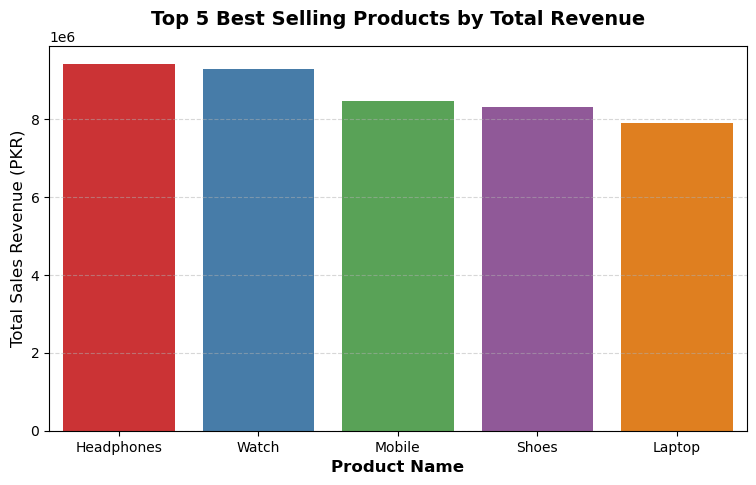

      product       total
0  Headphones  9414259.95
1       Watch  9295181.97
2      Mobile  8478520.28
3       Shoes  8304435.17
4      Laptop  7908062.14


In [28]:
# 1. Products ki total sales calculate kar ke top 5 nikalna
top_5_products = (
    df.groupby("product")["total"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .reset_index()
)

# 2. Seaborn Bar Chart banana
plt.figure(figsize=(9, 5))
sns.barplot(
    data=top_5_products,
    x="product",
    y="total",
    palette="Set1",
    hue="product",
    legend=False,
)

# Graph ki styling aur titles
plt.title("Top 5 Best Selling Products by Total Revenue", fontsize=14, pad=15, fontweight = "bold")
plt.xlabel("Product Name", fontsize=12, fontweight = "bold")
plt.ylabel("Total Sales Revenue (PKR)", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Chart display karna
plt.show()

# Values print karke dekhna
print(top_5_products)

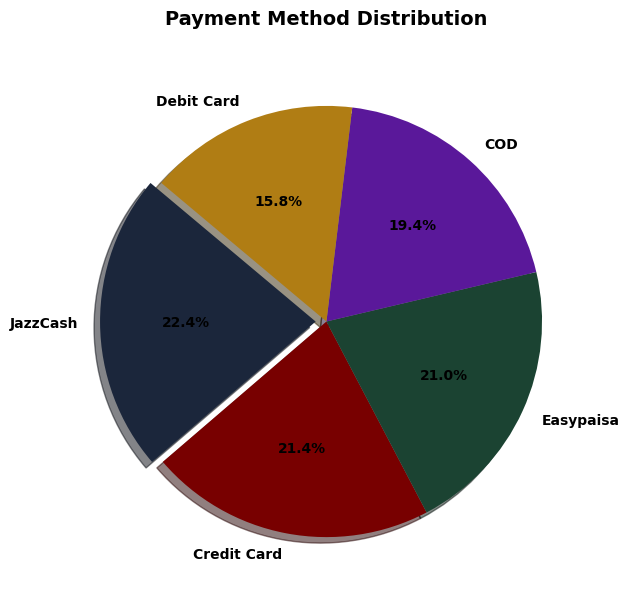

payment_method
JazzCash       112
Credit Card    107
Easypaisa      105
COD             97
Debit Card      79
Name: count, dtype: int64


In [36]:
# 1. Har Payment Method ke orders count karna
payment_counts = df["payment_method"].value_counts()

# 2. multi colors ki list
dark_colors = [
    "#1B263B", 
    "#780000",  
    "#1B4332",  
    "#5A189A",  
    "#B07D14",  
]

# 3. Pie chart mein colors pass karein
plt.figure(figsize=(7, 7))
plt.pie(
    payment_counts,
    labels=payment_counts.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=dark_colors,  
    explode=(0.05, 0, 0, 0, 0),
    shadow=True,
    textprops={"color": "black", "fontsize": 10, "weight": "bold"},
)

plt.title("Payment Method Distribution", fontsize=14, weight="bold", pad=20)
plt.show()

# Table ki shakal mein counts dekhnay ke liye
print(payment_counts)

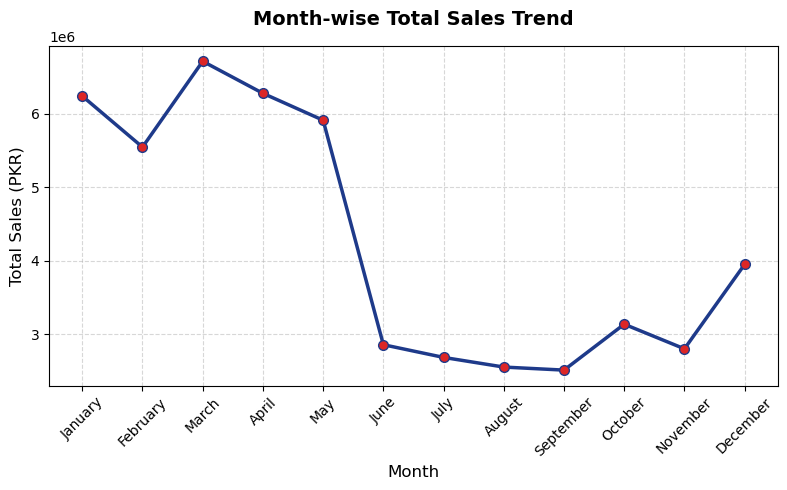

Month
January      6238414.59
February     5545040.22
March        6711119.66
April        6275753.74
May          5909845.92
June         2860920.11
July         2688475.62
August       2557288.54
September    2515916.08
October      3139444.82
November     2805153.37
December     3952563.75
Name: total, dtype: float64


In [37]:
# 1. Mahinon ki sahi tarteeb tay karna
months_order = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December",
]

# 2. Har mahinay ki total sales calculate karna aur tarteeb dena
monthly_sales = df.groupby("Month")["total"].sum().reindex(months_order)

# 3. Matplotlib Line Chart banana
plt.figure(figsize=(8, 5))
plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o",
    linewidth=2.5,
    color="#1E3A8A",  
    markersize=7,
    markerfacecolor="#DC2626",  
)

# Styling, Labels aur Title
plt.title("Month-wise Total Sales Trend", fontsize=14, weight="bold", pad=15)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Total Sales (PKR)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)

# Chart display karna
plt.tight_layout()
plt.show()

# Monthly sales values display karna
print(monthly_sales)

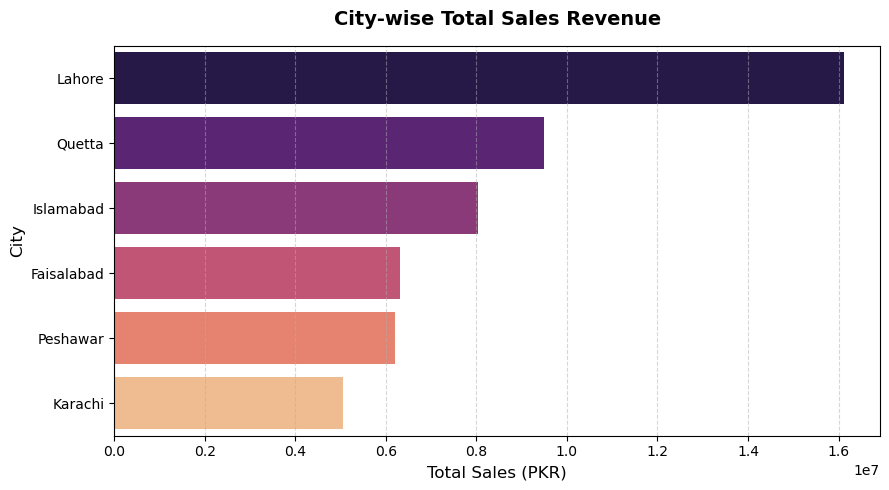

         City        total
0      Lahore  16108573.11
1      Quetta   9488620.43
2   Islamabad   8028811.58
3  Faisalabad   6318998.97
4    Peshawar   6194016.19
5     Karachi   5060916.14


In [38]:
# a) City codes ko asal shehron ke naam se replace karna
city_mapping = {
    1.0: "Karachi",
    2.0: "Lahore",
    3.0: "Islamabad",
    4.0: "Faisalabad",
    5.0: "Quetta",
    6.0: "Peshawar",
}
df["City"] = df["City"].map(city_mapping)

# Shehar ke hisaab se total sales calculate karna aur descending order mein lana
city_sales = (
    df.groupby("City")["total"].sum().sort_values(ascending=False).reset_index()
)

# b) Seaborn Horizontal Bar Chart banana
plt.figure(figsize=(9, 5))
sns.barplot(
    data=city_sales,
    y="City",  # Y-axis par City (is se horizontal bars banti hain)
    x="total",  # X-axis par Sales Revenue
    palette="magma",  # Modern vibrant dark color palette
    hue="City",
    legend=False,
)

# Chart labels aur title
plt.title("City-wise Total Sales Revenue", fontsize=14, weight="bold", pad=15)
plt.xlabel("Total Sales (PKR)", fontsize=12)
plt.ylabel("City", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.5)

# Display chart
plt.tight_layout()
plt.show()

# Values print karke dekhna
print(city_sales)

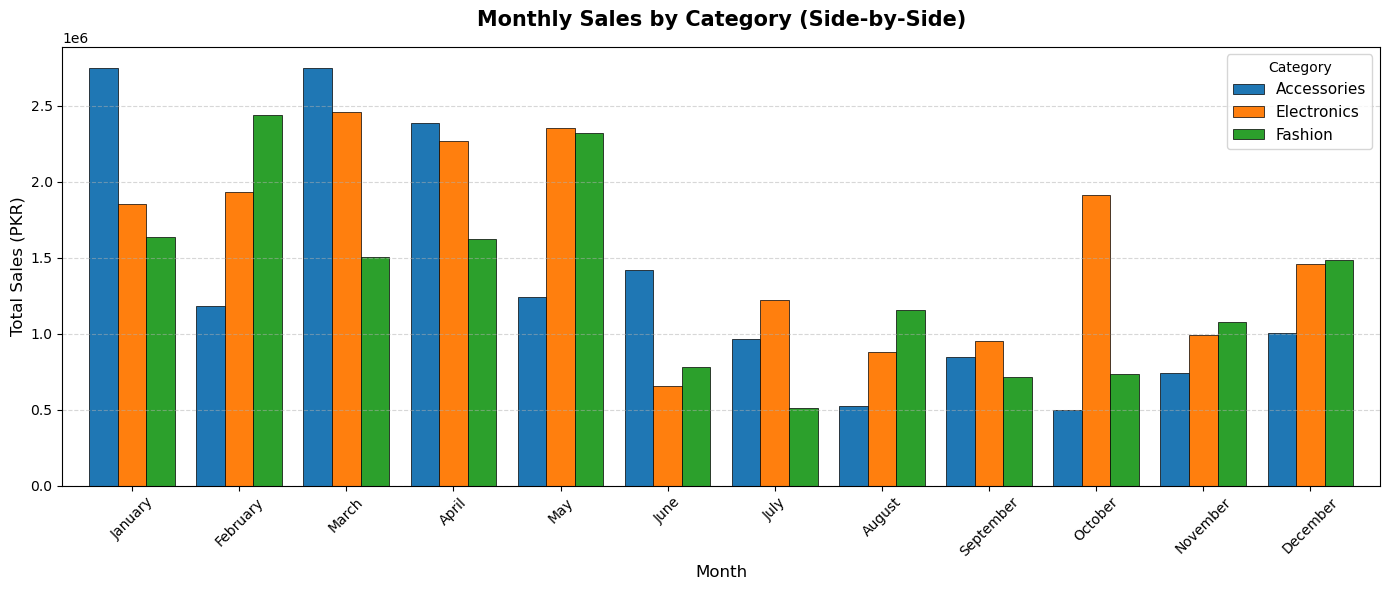

category   Accessories  Electronics     Fashion
Month                                          
January     2745729.82   1855039.15  1637645.62
February    1178881.69   1929360.80  2436797.73
March       2749630.71   2457415.74  1504073.21
April       2387980.38   2265079.20  1622694.16
May         1240740.21   2352232.89  2316872.82
June        1421673.13    657353.10   781893.88
July         961408.72   1218489.97   508576.93
August       521529.94    881950.11  1153808.49
September    849152.91    952931.97   713831.20
October      496080.70   1911295.72   732068.40
November     739060.88    991960.56  1074131.93
December    1005459.07   1460885.05  1486219.63


In [39]:
# 1. Calendar order tay karna
months_order = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December",
]

# 2. Pivot Table banana: Rows mein Months aur Columns mein Categories ki Total Sales
monthly_category_sales = df.pivot_table(
    index="Month", columns="category", values="total", aggfunc="sum"
).reindex(months_order)

# 3. Side by Side Bar Chart banana (Matplotlib)
fig, ax = plt.subplots(figsize=(14, 6))

# Matplotlib par grouped bars plot karna
monthly_category_sales.plot(
    kind="bar",
    ax=ax,
    width=0.8,
    color=["#1f77b4", "#ff7f0e", "#2ca02c"],  
    edgecolor="black",
    linewidth=0.5,
)

# Graph styling aur labels
plt.title(
    "Monthly Sales by Category (Side-by-Side)",
    fontsize=15,
    weight="bold",
    pad=15,
)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Total Sales (PKR)", fontsize=12)
plt.xticks(rotation=45)
plt.legend(title="Category", fontsize=11)
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Chart display karna
plt.tight_layout()
plt.show()

# Table ki shakal mein values dekhna
print(monthly_category_sales)